## 연관 분석 + 경영 기초 사전과제

## 1. 연관 분석

### 연관 분석

상품이나 서비스를 구매하는 등 일련의 거래나 사건 안에 존재하는 항목 간의 **일정한 연관 규칙**을 발견하는 분석  
- 정답값 존재 X -> 비지도 학습
- 알고리즘: ```Apriori```, ```FP-Growth```  
  
> 연관규칙 분석  

**연관규칙의 형태**  
- ```if-then``` 형식, ```A->B```로 표현 됨 (ex. 'A를 구매하였을 때, B 또한 구매할 것이다')
    - 조건절: '만일 ~라면'에 해당
    - 결과절: 그 뒷부분에 해당
    - 아이템 집합: 조건절 또는 결과절을 구성하는 아이템의 집합
        - 아이템 집합에는 여러 개의 아이템이 들어가도 되지만, 상호 배반이어야 함
  
  
**연관규칙 주의: 인과관계는 알 수 없다!**  
- 연관규칙으로는 상관관계만 알 수 있음!
    - 왜?
    1. 실험이 아닌 관찰 데이터라서 (다른 요소들이 통제되지 않음)
    2. 방향성은 그냥 수학적 비율 (A->B에서 화살표가 원인이라는 의미 아님)
    3. 상관관계!=인과관계
  
**연관 분석 vs 협업 필터링**  
- 연관 규칙 분석은 추천 시스템의 하위 or 초기 개념으로 분류하기도 함
- 협업 필터링은 평가점수와 구매횟수 등 복잡한 수치를 계산할 수 있음 -> 개인화된 상품 추천
- 연관 분석은 상품이 포함된 비율만 계산하는 대신, 다양한 세트상품 뽑아낼 수 있음 -> 상푼 노출 또는 세트 구성에 활용
  
---
*연관분석*: 같이 들어 있는 비율  
- 연산 방식: 교집합 기반
- 알고리즘 구조: 상품마다 주문 내역을 1:n 계산 (특정 상품이 포함된 구매 데이터에서 다른 상품의 비율을 계산)
- 특징: 상품과 연관성이 높은 1개 이상의 상품을 세트로 추출
- 추천 방식: 연관지표가 높은 세트상품(1개 이상) 노출
---
*상품기반 협업 필터링*: 같이 증가하거나 감소  
- 연산 방식: 상관관계 기반
- 알고리즘 구조: 상품마다 타 상품과 1:1 계산 (특정 상품의 구매 데이터를 다른 상품의 구매 데이터와 비교)
- 특징: 사용자의 개인 선호도(평가점수, 구매횟수 등)에 따라 선호 상품 추출 가능
- 추천 방식: 타 상품의 유사도 순위대로 노출


### 주요 개념

> 연관규칙의 조건  

1. *일정 이상의 지지도*: 두 품목이 함께 구매한 경우의 수가 일정 수준 이상이어야 함
2. *일정 이상의 신뢰도*: 품목 A를 포함하는 거래 중 품목 B를 구입하는 경우의 수가 일정 수준 이상이어야 함
  
**지지도**: 전체 거래 항목 중 품목 A와 B가 동시에 포함되는 전체 거래의 비율  
- $지지도=P(A\cap B)$
- 이 규칙이 현실에서 의미 있는가를 판단하는 1차적 기준
- 지지도가 낮으면 현실 적용 불가
  
**신뢰도**: 품목 A를 포함하는 거래 수 중 품목 A와 B가 동시에 포함하는 거래의 비율  
- $신뢰도=\frac{P(A\cap B)}{P(A)}=\frac{지지도}{P(A)}$
- 신뢰도가 낮으면 의미 없는 연관 규칙임
  
> 연관 분석의 평가 측도  

**향상도**: 품목 A가 주어지지 않았을 때의 품목 B 확률 대비, 품목 A가 주어졌을 때 품목 B 확률의 *증가 비율*  
- $향상도=\frac{P(A\cap B)}{P(A)P(B)}=\frac{신뢰도}{P(B)}$
- A와 B가 우연이 함께 등장할 확률과 실제 함께 등장할 확률을 비교하자
  
1. 독립일 때 기댓값
- 확률에서 사건 A와 B가 독립이라면
    - $P(A\cap B)=P(A)*P(B)$
    - A를 샀다는 사실이 B를 살 확률에 영향 주지 않음
    - 향상도=1
- 확률에서 사건 A와 B가 독립이 아니라면
    - $P(A\cap B)=P(A)*P(B\mid A)=P(B)*P(A\mid B)$
    - A를 샀다는 사실이 B 살 확률에 영향 주거나, B를 샀다는 사실이 A 살 확률에 영향을 줌
    - 실제로 관측한 $P(A\cap B)$에 따라 향상도는 1보다 크거나, 1보다 작음
  
2. 실제 동시 발생 확률
- $P(A\cap B)$가 A와 B가 함께 등장할 확률의 기댓값 $P(A)*P(B)$보다
    - 크면 -> 양의 연관성
    - 작으면 -> 음의 연관성
  
3. 비율로 비교 -> 향상도
- 향상도>1: 우연적 기회보다 높은 확률 (양의 상관관계)
- 향상도=1: 독립
- 향상도<1: 우연적 기회보다 낮은 확률 (음의 상관관계)
  
*규칙의 효용성은 지지도, 신뢰도, 향상도 세 지표 모두를 반영!*  

### 활용 사례
  
> Netflix Case: 첫 오리지널 콘텐츠 <하우스 오브 카드> 제작 투자  

- 과감한 투자의 근거로 삼은 데이터
    - 데이비드 핀쳐 감독의 영화는 시청 완료율이 높음
    - 영국판 <하우스 오브 카드>가 인기 있음
    - 영국판 <하우스 오브 카드>를 본 사람들은 케빈 스페이시가 출연한 영화나 데이비드 핀쳐 감독의 영화를 봄
- 연관 분석 관점
    - 지지도: "영국판 <하우스 오브 카드>를 본 사람 중 상당수가 케빈 스페이시가 출연한 콘텐츠도 시청함"
        -> 영국판 <하우스 오브 카드> ${\cap}$ 케빈 스페이스 콘텐츠
    - 신뢰도: $P(\text{시청 완료율}\mid \text{데이비드 핀처 콘텐츠})$ 높았음
    - 향상도: 영국판 <하우스 오브 카드>와 케빈 스페이스 콘텐츠 시청의 향상도가 1보다 큼

### 연관 분석 알고리즘

> Apriori 알고리즘  

**배경**  
- 연관 규칙을 찾기 위해 가능한 모든 조합 시도하는 건 비효율적
    - 상품 개수 많아질수록 조합의 수는 기하급수적으로 증가
  
**Apriori 알고리즘**  
- 개념: 상위 조합에서부터 차례로 스캔하면서 특정 조합 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합까지 모두 후보에서 배제
- 장점: 하나의 조합만 검사하고도 이에서 파생된 다른 조합까지 후보에세 배제 가능
    - 시간과 연산량 효과적으로 감소
  
**Apriori 알고리즘 프로세스**  
- 빈발 항목 집합 발견 -> 단계적으로 조합 생성하고 필터링
    - 빈발 항목 집합: 일정한 최소 지지도를 넘는 항목들의 조합
  
1. 단일 항목 집합 생성
    - 모든 개별 상품에 대해 지지도 계산
    - 최소 지지도를 넘는 항목들만 다음 단계로
2. 2개 항목 집합 생성
    - 1단계에서 선별된 상품들로 2개 항목의 조합
    - 지지도 계산 후 최소 지지도를 넘지 않는 조합 제거
3. 더 큰 항목 집합 생성
    - 남은 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합 만듦
    - 지지도 계산 -> 최소 지지도 넘지 않는 조합 제거
    - 더 이상 조합을 생성할 수 없을 때까지 이 과정 반복
4. 최종 빈발 항목 집합 선정
    - 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관 규칙 생성
    - 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙 선택
  
**장단점**  
- 장점
    - 수많은 상품 연관 구매 패턴 발견
    - 원리 간단, 이해 분석 용이
- 단점
    - 데이터 커질수록 속도 느려짐
  
**코드**  
```
from mixtend.frequentpatterns import apriori
from mixtend.frequentpatterns import association_rules

frequent_itemsets= apriori(df, min_support=0.06, use_colnames=True)
reles=association_rules(frequent_itemsets, metric='confidence', min_threshold=0.8)
top_rules=rules.sort_values(by='lift', ascending=False).head()
```
  
  
> FP Growth 알고리즘

**배경**  
- Apriori 알고리즘은 여전히 데이터가 커질수록 속도가 느려짐
    - 각 단계에서 데이터를 다시 스캔해야 하기 때문
  
**FP-Growth 알고리즘**  
- 빈발 품목 집합을 효율적으로 찾아냄
- FP-Tree 구조를 이용해 Apriori를 효과적으로 구현
- Tree, Array, Linked_List를 합쳐놓은 구조
- 모든 거래를 확인해 각 아이템마다 지지도를 계산, 최소 지지도 이상의 아이템만 선택
    - 모든 거래에서 빈도가 높은 아이템 순서대로 순서를 정렬
    - 부모 노드 중심으로 거래를 자식 노드로 추가해주며 tree 생성
    - 새로운 아이템이 나올 경우 부모 노드부터 시작하고, 그렇지 않으면 기존 노드에서 확정
    - 해당 과정을 모든 거래에 대해 반복하여 FP Tree 만들고 최소 지지도 이상의 패턴만 추출
  
**FP-Growth 알고리즘 프로세스**  
- 모든 항목의 빈도를 계산한 후, 최소 지지도 이상인 항목만을 남김
  
1. 데이터셋 확인
2. 빈도순 재정렬: 남은 항목들을 각 거래별로 빈도순으로 재정렬
3. FP-Tree 생성: 각 거래를 노드로 표현, 동일한 항목은 기존 노드에 연결해 빈도 증가 / 새로운 항목은 새로운 노드로 추가
4. 빈발 항목 집합 추출: FP-Tree 바탕으로 특정 항목을 기준으로 부분 트리를 만들어 빈발 항목 집합 추출
5. 연관 규칙 도출: FP-Tree에서 도출된 빈발 항목 집합을 바탕으로 연관 규칙 만듦. 각 규칙에 대해 지지도, 신뢰도, 향상도 등 지표를 계산해 가장 유용하 규칙 선택
  
**장단점**  
- 장점
    - 데이터를 두 번만 스캔하는 Tree 구조, Apriori보다 훨씬 빠름
    - 후보 Itemset 생성할 필요 없이 Tree만 구성하면 끝
- 단점
    - 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않음
    - Apriori에 비해 설계하기 어렵고, 지지도의 계산은 무조건 FP-Tree가 만들어져야 가능
  
**코드**  
```
from mlxtend.frequent_pattenrs import fpgrowth
from mlxtend.frequent_pattenrs import association_rules

frequent_itemsets=fpgrowth(df, min_support=0.06, use_colnames=True)
rules=association_rules(frequent_itemsets, metric='confidence', min_threshold=0.8)
```

## 2. 경영 기초

### 문제 정의와 구조화

> 문제 정의  

문제: 현재의 상태와 바라는 상태 사이의 격차  
- 현상은 관찰된 사실, 문제는 해결해야 할 질문
- 단순히 나쁜 상황을 나열하는 것은 문제 아님 -> 경영자가 '의사결정'을 내려야 하는 구체적인 질문으로 치환했을 때 비로소 '문제'가 됨
  
**SMART 원칙**  
- Specific: 구체적이고 명확 / 무엇을, 어디까지 풀지 명확히 정의
- Measurable: 수치로 측정 가능 / 성공 여부를 수자로 판단 가능
- Action-oriented: 실행 지향적, 결과 중심적 / 행동을 이끌어내고 성과에 집중
- Relevant: 관련성 / 조직의 목표와 관련이 있어야 함
- Time-bound: 시한성 / 마감 기한과 의사 결정 시점 존재
  
**문제 구조화**  
- 거대한 문제를 해결 가능한 하위 문제로 분해
- MECE: 문제를 쪼갤 때 지켜야 하는 철칙
    - Mutually Exclusive: 겹치는 부분 X
    - Collectively Exhaustive: 누락된 부분 X
- MECE 규정
    1. 논리적 일관성: 한 층위에서는 하나의 기준으로 나눔
    2. 통찰력: 문제를 해결하는 데 도움이 되는 기준으로 나눔
    3. 생호 배타성: 조각들이 서로 겹치지 않아야 분석 결과 명확

### 지표

> 지표  

- 방향이나 목적, 기준 따위를 나타내는 표지  
- 추상적인 개념과 관련되는 지수, 척도
- 측정하고 싶은 것을 숫자로 표현한 것
  
$$metrics=\frac{numerator}{denominator}$$
  
**지표 유형**  
- 효율성: 산출/투입 (ex. 노동생산성=생산량/노동시간)
- 효과성: 달성결과/목표 (ex. 목표달성률=실제매출/목표매출)
- 수익성: 이익/자원 (ex. ROE=순이익/자기자본)
- 성장성: 증가분/기준규모 (ex. 매출성장률=(당기매출-전기매출)/전기매출)
- 안정성: 보유자산/부채 (ex. 부채비율=부채/자기자본)
(+) 절대치 지표, 지수형 지표, 복합 지표 등  
  
> Proxy Metric  

- 추상적이어서 프로덕트마다 나름의 가정과 정의, 논의가 필요한 지표 (ex. 활성화, 인게이지)
- 궁금하지만 직접 측정할 수 없으니 대체물(Proxy)을 정하여 측정
- Proxy 설정 자체에 많은 논의가 필요하고 정답 별도로 존재하지 않음
  
> 북극성 지표 L1/L2 Metrics  

- 북극성 지표: 기업에 가장 중요하게 생각하는 지표
- L1 지표: 전사적인, 고수준의 평가 지표 (전략 관점)
- L2 지표: L1 지표의 세부 사항을 측정하는 지표 (전술 관점)
  
- KPI: Key Performance Indicator. 핵심성과지표.
- OKR: 궁극적으로 이루고자 하는 목표를 설장해 정량화된 핵심 결과를 도출
  
> AARRR (해적 지표)  

AARRR 모델: 사용자 운영 과정에서 자주 활용하는 데이터 분석 모델, 사용자 증가를 위한 5가지 로드맵 구성
  
1. Acquistion
- 사용자 획득, 사용자가 다양한 채널을 통해 앱 혹은 웹사이트에 방문하는 것
- 채널: 광고, 검색엔진 최적화(SEO), 지인 추천, 오프라인 행사 등
- '신규 고객을 어떻게, 어디로부터 획득할지'
- 지표: CAC, CTR, CPC, CPL, ROAS
  
2. Activation
- 사용자 활성화, 사용자가 앱 또는 웹에 첫 방문하여 주요 기능을 직접 사용하는 것
- 제품의 성격에 따라 다양한 기준으로 측정
- 단계: Sigh-up -> Setup Moment -> A-HA! Moment -> Habit Moment
  
3. Retention
- 유지 단계, 신규 사용자를 장기 사용자로 전환시키는 것
- '어떻게 장기 고객을 양성할 것인지', '어떻게 고객의 지속적인 구매 행위를 증가시킬 수 있을지'
- 지표: DN Retention, MAU/DAU/WAU, Stickness(DAU, MAU)
  
4. Revenue
- 수익 단계, 사용자가 제품 혹은 서비스를 유료 구매하기로 결정한 단계
- 고객의 평생 가치(LTV)를 지속적으로 높여 나가고, 고객 유치 비용은 계속해서 줄여나가야 함
- 지표: PU, Average Check, ARPU, ARPPU, LTV
  
5. Referral
- 추천 단계, 사용자가 상품 혹은 서비스에 만족하여 타인에게 추천한 것
- 제품의 지속적 성장을 위해 중요한 단계
- '어떻게 충성도 높은 사용자를 보이지 않는 브랜드 홍보자로 만들지', '어떻게 제품을 잠재 고객들에게 추천하도록 만들지'
- 지표: 바이럴 계수, NPS

### 지표 분석 방법

> 코호트 분석  

- 코호트: 동질 집단
    - 정의된 시간 범위 내에서 공통된 특성, 경험을 공유하는 사용자 집단
- 분석 전에 데이터 세트의 데이터를 관련 그룹으로 나누는 일종의 행동 분석
- 시간(날짜)에 기반하는 사용자 세그먼트를 분류
    - 세그먼트에 기간이라는 개념을 포함
- 주로 사용자 유지, 이탈을 체크하는 데 많이 사용
  
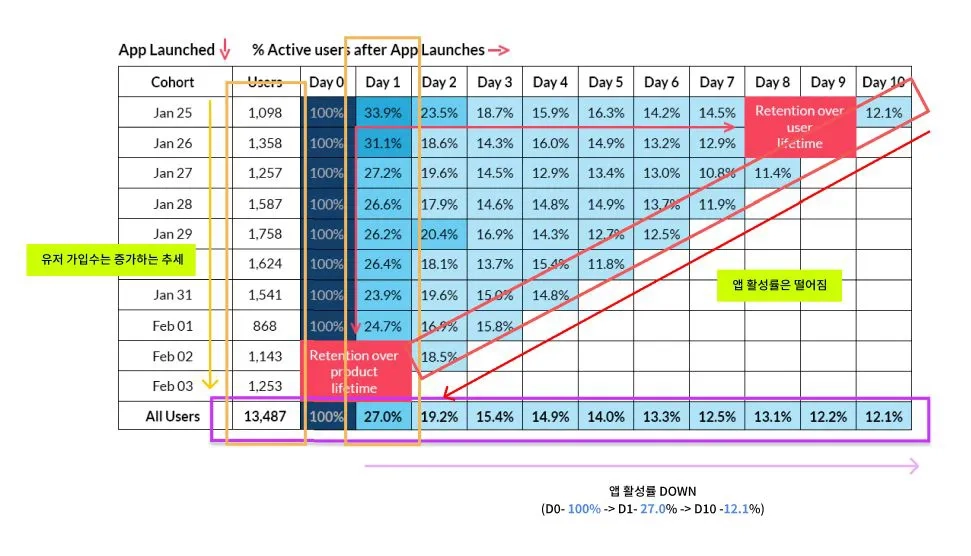  
  
- 세로축: 코호트별 비교
- 대각선: 시점별 비교
- 가로축: 시간의 경과에 따른 변화
  
> 퍼널 분석  

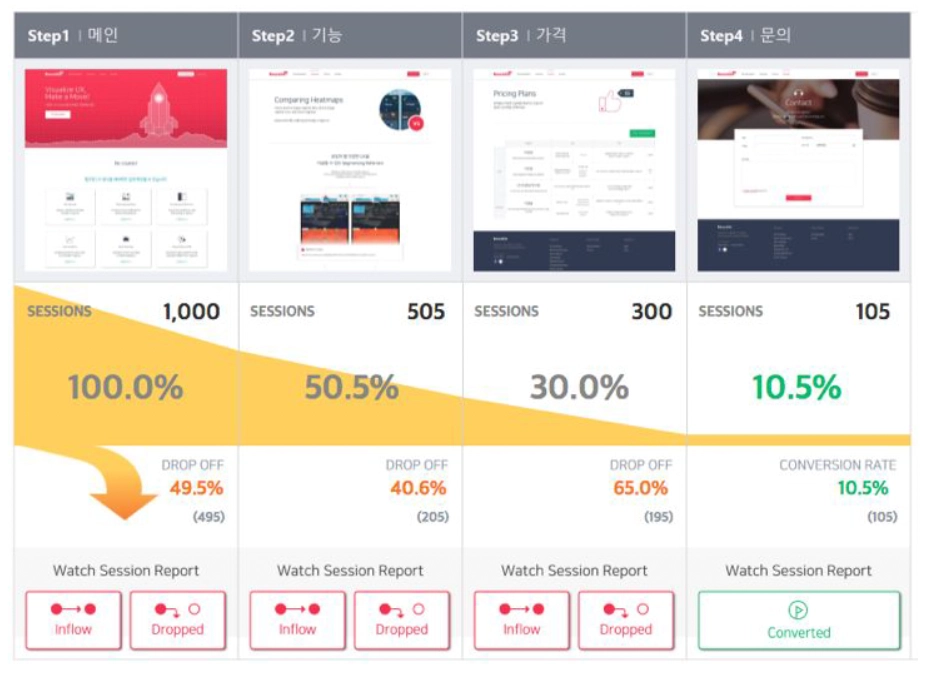  
  
- 유저가 접속해서 떠날 때까지 유저의 행동을 추적
- 아래로 갈수록 점점 좁아짐 (=시간이 지날수록 유저 이탈)
  
**개선 방법 예시**  
1. 유입률 높이기
2. 전환율 높이기
3. 퍼널 단계 없애기
4. 퍼널 순서 바꾸기
5. 퍼널 단계 추가하기
6. 코호트로 나누어 보기